# Ex.No.8 - Decision Trees

* _Name: Monish D.Y._
* _Roll No.: 230701195_
* _Date: 17/03/2026_

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [51]:
# Load Dataset
data = pd.read_csv(r"D:\VI\FOML\Datasets\Drug Prediction.csv")
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [52]:
# Encode Categorical Columns
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
le_drug = LabelEncoder()

data['Sex'] = le_sex.fit_transform(data['Sex'])
data['BP'] = le_bp.fit_transform(data['BP'])
data['Cholesterol'] = le_chol.fit_transform(data['Cholesterol'])
data['Drug'] = le_drug.fit_transform(data['Drug'])

# Define Features and Target
X = data[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]
y = data['Drug']

X

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043
...,...,...,...,...,...
195,56,0,1,0,11.567
196,16,1,1,0,12.006
197,52,1,2,0,9.894
198,23,1,2,1,14.020


In [69]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree Model
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)
model

DecisionTreeClassifier(random_state=42)

In [70]:
# Prediction and Accuracy
y_pred = model.predict(X_test)

print("Train Accuracy :", model.score(X_train, y_train))
print("Test Accuracy  :", model.score(X_test, y_test))

Train Accuracy : 1.0
Test Accuracy  : 1.0


<Figure size 800x600 with 0 Axes>

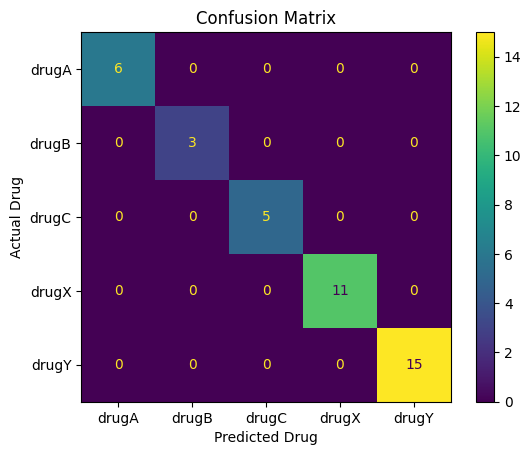

In [79]:
# Confusion Matrix with Drug Names

cm = confusion_matrix(y_test, y_pred)

drug_names = le_drug.classes_

plt.figure(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=drug_names
)

disp.plot()

plt.title("Confusion Matrix")
plt.xlabel("Predicted Drug")
plt.ylabel("Actual Drug")

plt.show()

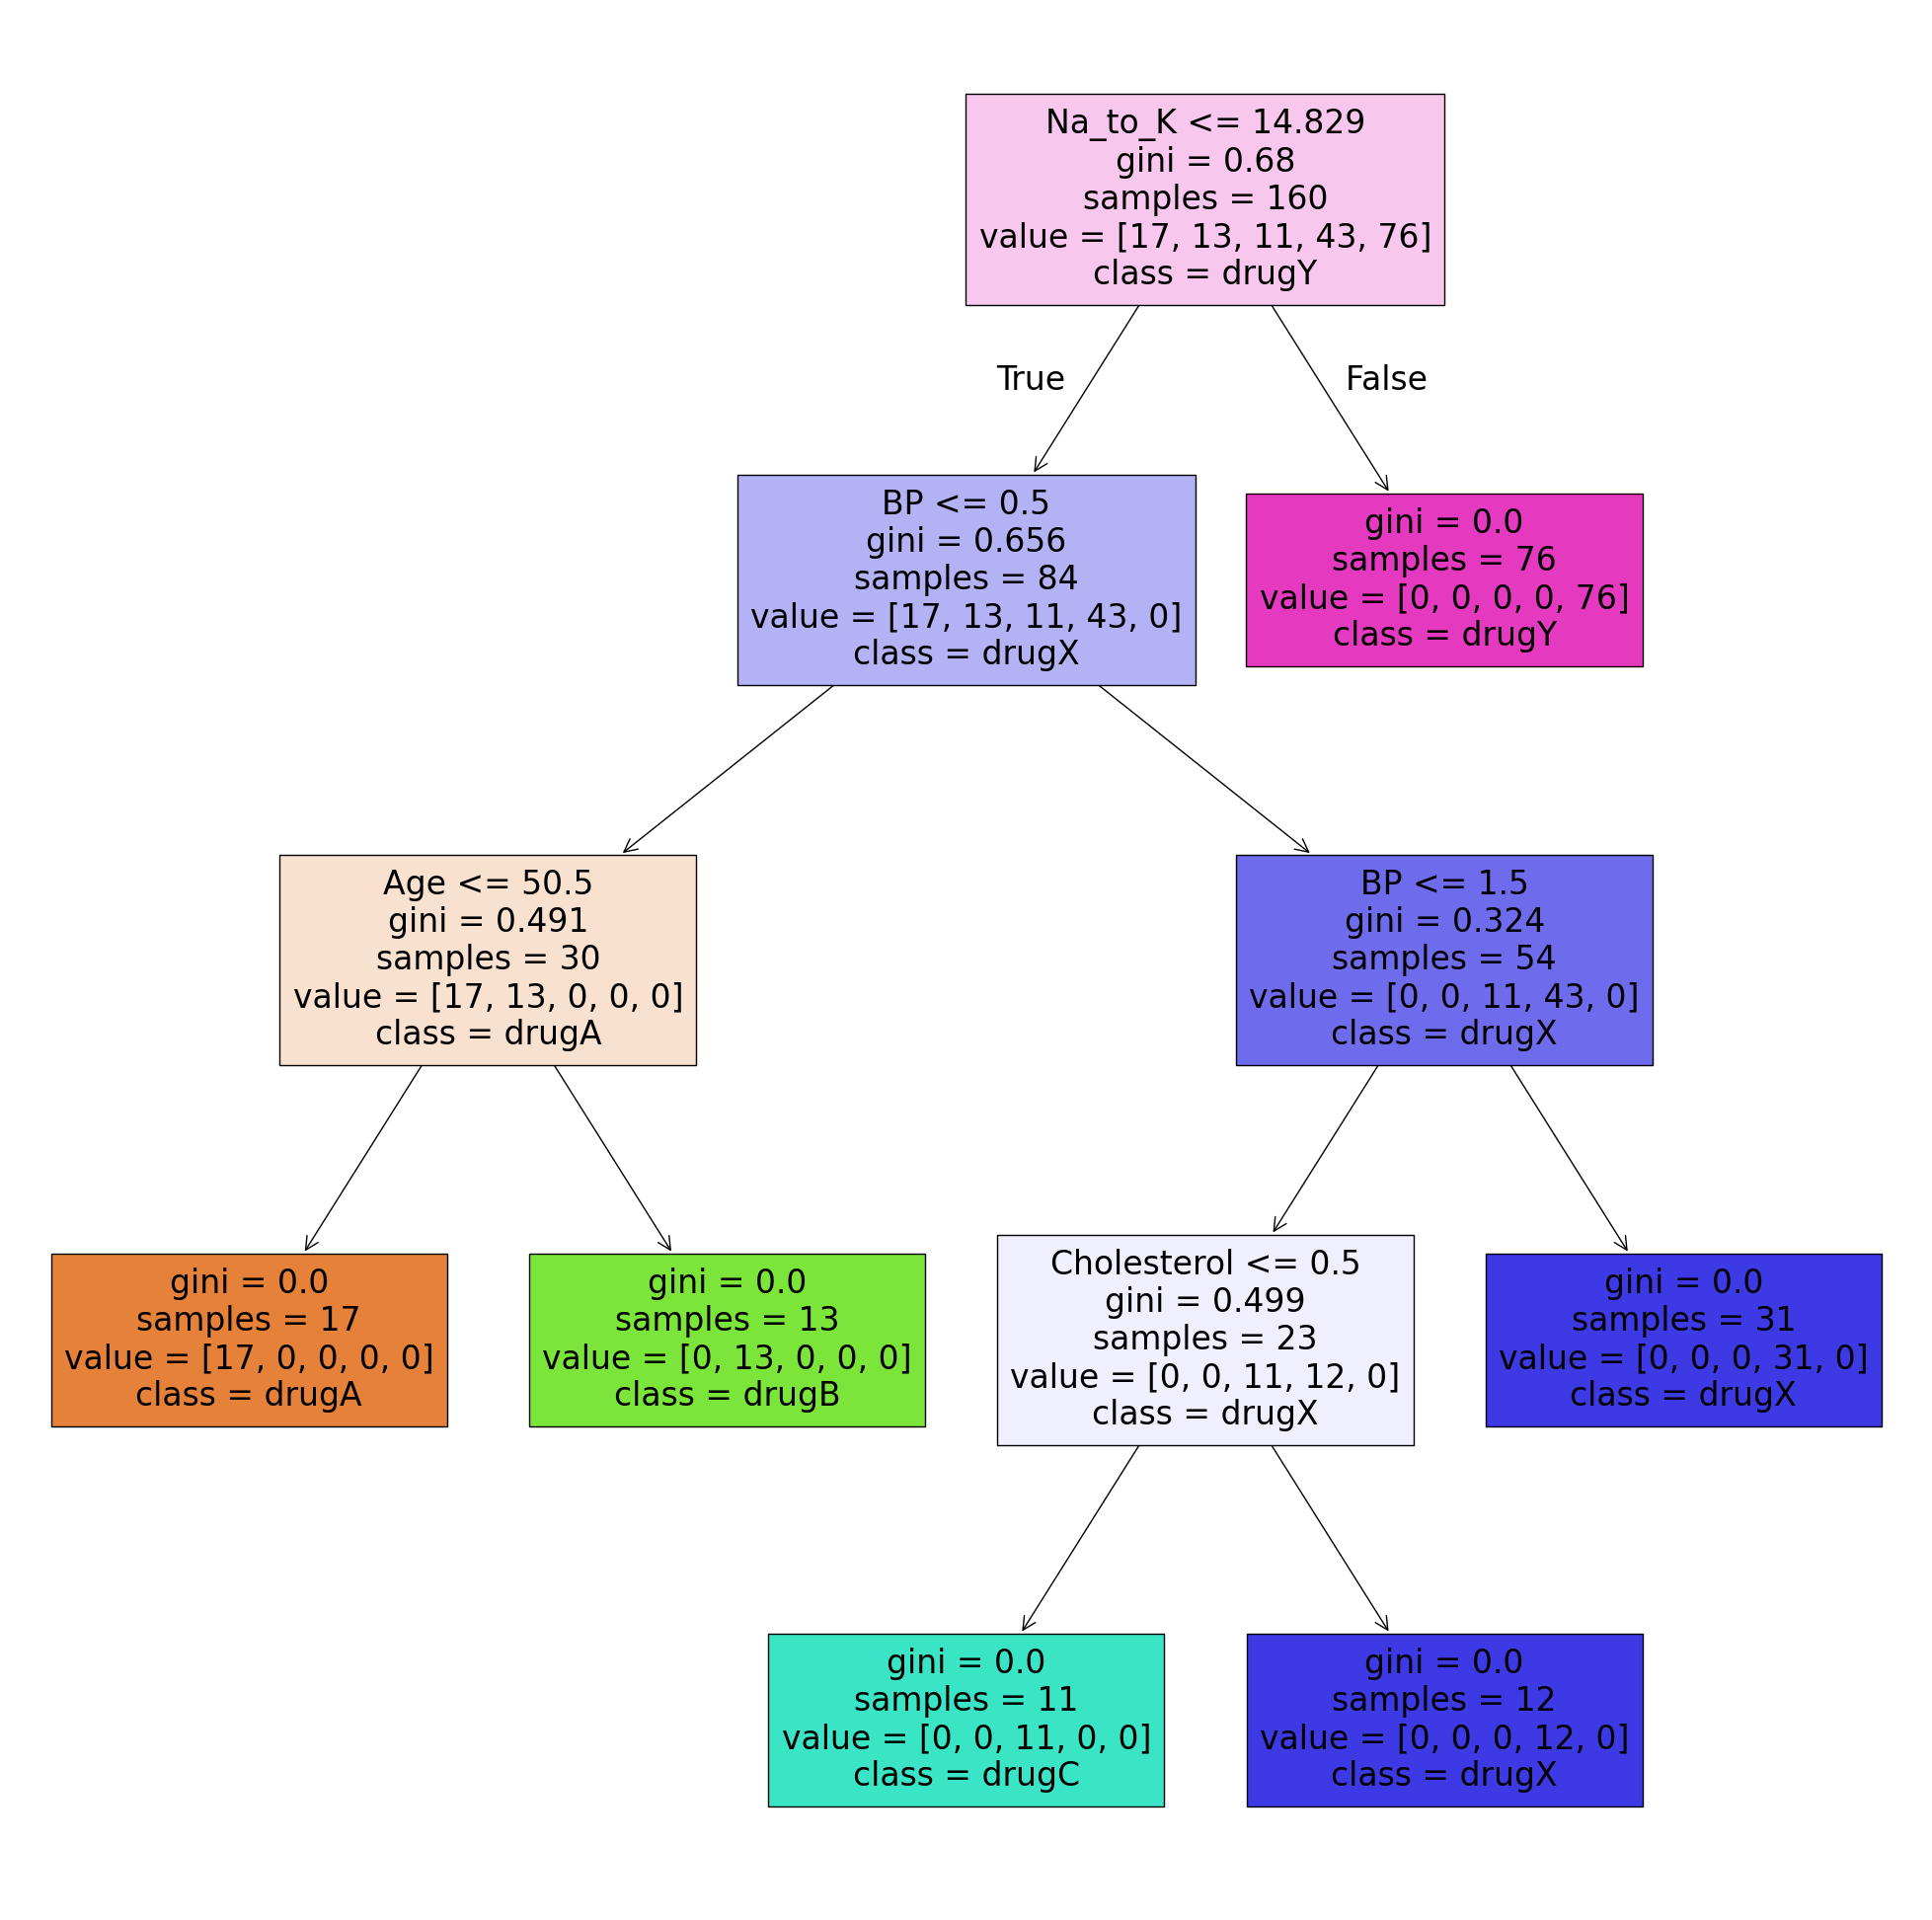

In [80]:
# Decision Tree Visualization
plt.figure(figsize=(25,25))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=le_drug.classes_,
    filled=True
)

plt.savefig(r"D:\VI\FOML\Outputs\decision_tree.png", dpi=300, bbox_inches='tight')
plt.show()

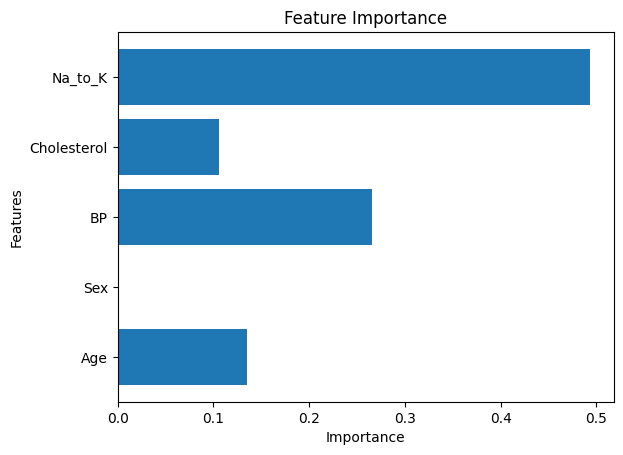

In [73]:
importance = model.feature_importances_

plt.figure()
plt.barh(X.columns, importance)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()

In [74]:
# Custom Data Prediction
# [Age, Sex, BP, Cholesterol, Na_to_K]

sample = [[47, 1, 0, 0, 14.5]]

prediction = model.predict(sample)

print("Predicted Drug :", le_drug.inverse_transform(prediction)[0])

Predicted Drug : drugA


C:\Users\Monish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
